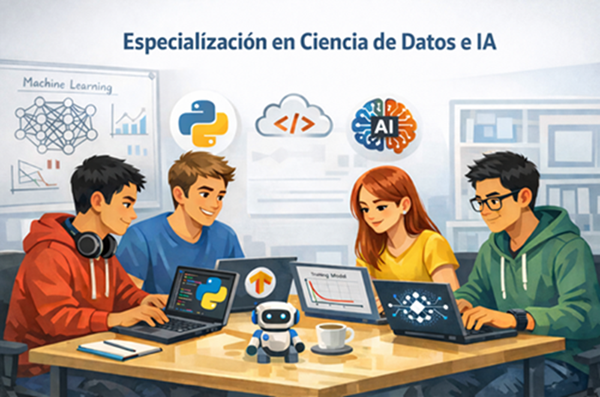

# MLOps - Parte I
## Análisis Exploratorio de Datos (EDA) del Secondary Mushroom Dataset

**Curso:** MLOps
**Profesora:** Maria Camila Durango Barrera  
**Dataset:** Secondary Mushroom Dataset  
**Fuente:** UCI Machine Learning Repository  
**Integrantes:** Daniela Gutierrez Garces, Carlos Andrés Morcillo Tapia, Andrés Felipe Lopez, Yessid Alejandro Restrepo Villa  
**Fecha:** 06 de abril de 2026

---


## 1. Introducción

Como parte de la primera entrega del curso de MLOps, este proyecto presenta un Análisis Exploratorio de Datos (EDA) del **Secondary Mushroom Dataset** del **UCI Machine Learning Repository**.

El dataset escogido es una dataset tabular de UCI para clasificación binaria que contiene alrededor de 61 mil observaciones de hongos simulados y 20 variables predictoras. Su objetivo es determinar si un hongo es comestible o venenoso, usando una combinación de variables numéricas y categóricas, lo que lo hace adecuado para análisis exploratorio, preprocesamiento y futuros modelos de machine learning.

En esta primera etapa, el enfoque no está en construir un modelo final de aprendizaje automático, sino en comprender la estructura, la calidad y los principales patrones de los datos. Este análisis servirá como base para etapas posteriores relacionadas con el preprocesamiento, el modelado, la orquestación y el despliegue dentro de un flujo de trabajo de MLOps.


## 2. Objetivo General

Realizar un Análisis Exploratorio de Datos (EDA) del **Secondary Mushroom Dataset** con el fin de comprender su estructura, identificar problemas de calidad de los datos, explorar variables numéricas y categóricas, analizar las relaciones entre las características y generar hallazgos que puedan orientar futuras etapas de aprendizaje automático y MLOps.


## 3. Objetivos Específicos

- Cargar e inspeccionar la estructura del dataset.
- Identificar valores faltantes, duplicados y posibles inconsistencias.
- Describir las variables numéricas y categóricas.
- Visualizar la distribución de la variable objetivo y de las características más relevantes.
- Analizar las correlaciones entre las variables numéricas.
- Extraer hallazgos clave que puedan apoyar futuras decisiones de preprocesamiento y modelado.


## 4. Descripción del Dataset

El **Secondary Mushroom Dataset** fue obtenido del **UCI Machine Learning Repository**.  
Contiene más de sesenta mil observaciones de hongos e incluye tanto variables **continuas** como **categóricas**. La variable objetivo indica si un hongo es **comestible** o **venenoso**.


## 5. Pregunta Orientadora

¿Qué patrones, distribuciones, problemas de calidad de datos y relaciones pueden identificarse en el **Secondary Mushroom Dataset** antes de avanzar hacia las etapas de preprocesamiento y aprendizaje automático?


## 6. Carga de Librerías y del Dataset

En esta sección, importamos las librerías necesarias de Python y cargamos el dataset en un DataFrame de pandas para realizar una inspección inicial.


In [1]:
from __future__ import annotations

import sys
from pathlib import Path

import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from IPython.display import display

NOTEBOOK_DIR = Path.cwd().resolve()

if NOTEBOOK_DIR.name == "notebooks":
    PROJECT_ROOT = NOTEBOOK_DIR.parent
else:
    PROJECT_ROOT = NOTEBOOK_DIR

DATA_PATH = PROJECT_ROOT / "data" / "secondary_data.csv"
SRC_PATH = PROJECT_ROOT / "src"

print("Project root:", PROJECT_ROOT)
print("Data path:", DATA_PATH)
print("Src path:", SRC_PATH)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.dpi"] = 110

df = pd.read_csv(DATA_PATH, sep=";")
TARGET_COL = "class"                    # Incluímos el target en el DataFrame para facilitar su análisis

display(df.head())

Project root: G:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Mushroom
Data path: G:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Mushroom\data\secondary_data.csv
Src path: G:\Mi unidad\Programming\VSCode\Git\MLOps_UdeM_Mushroom\src


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w


## 7. Inspección Inicial de los Datos

El propósito de esta sección es comprender la estructura básica del dataset:
- número de filas y columnas,
- nombres de las variables,
- tipos de datos,
- registros de muestra,
- y metadatos generales.


📋 **Variables observadas**

| Variable | Descripción | Tipo de dato |
| --- | --- | --- |
| 🎯 **class** | **Variable objetivo**: clase del hongo (`e` = comestible, `p` = venenoso). | string *(object)* |
| 📏 **cap-diameter** | Diámetro del sombrero del hongo, medido en cm. | float64 |
| 📐 **stem-height** | Altura del tallo del hongo, medida en cm. | float64 |
| 📌 **stem-width** | Ancho del tallo del hongo, medido en mm. | float64 |
| 🍄 **cap-shape** | Forma del sombrero. | string *(object)* |
| 🧩 **cap-surface** | Textura o superficie del sombrero. | string *(object)* |
| 🎨 **cap-color** | Color del sombrero. | string *(object)* |
| 🩸 **does-bruise-or-bleed** | Indica si el hongo se magulla o sangra al manipularlo. | string *(object)* |
| 🌿 **gill-attachment** | Tipo de unión de las laminillas al tallo. | string *(object)* |
| ↔️ **gill-spacing** | Espaciamiento entre las laminillas. | string *(object)* |
| 🌈 **gill-color** | Color de las laminillas. | string *(object)* |
| 🌱 **stem-root** | Tipo de raíz o base del tallo. | string *(object)* |
| 🪵 **stem-surface** | Textura o superficie del tallo. | string *(object)* |
| 🟫 **stem-color** | Color del tallo. | string *(object)* |
| 🧣 **veil-type** | Tipo de velo presente en el hongo. | string *(object)* |
| 🎭 **veil-color** | Color del velo. | string *(object)* |
| 💍 **has-ring** | Indica si el hongo presenta anillo. | string *(object)* |
| 🔘 **ring-type** | Tipo de anillo. | string *(object)* |
| 🌫️ **spore-print-color** | Color de la impresión de esporas. | string *(object)* |
| 🌍 **habitat** | Hábitat donde se encuentra el hongo. | string *(object)* |
| 🍂 **season** | Estación del año en la que aparece el hongo. | string *(object)* |

In [2]:
print("Shape (rows, columns):", df.shape)
print("Column names:", list(df.columns))

display(df.head(10))
display(df.sample(n=min(10, len(df)), random_state=42))

df.info(memory_usage="deep")

df.dtypes

Shape (rows, columns): (61069, 21)
Column names: ['class', 'cap-diameter', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-height', 'stem-width', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
0,p,15.26,x,g,o,f,e,NaN,w,16.95,...,s,y,w,u,w,t,g,NaN,d,w
1,p,16.60,x,g,o,f,e,NaN,w,17.99,...,s,y,w,u,w,t,g,NaN,d,u
2,p,14.07,x,g,o,f,e,NaN,w,17.80,...,s,y,w,u,w,t,g,NaN,d,w
3,p,14.17,f,h,e,f,e,NaN,w,15.77,...,s,y,w,u,w,t,p,NaN,d,w
4,p,14.64,x,h,o,f,e,NaN,w,16.53,...,s,y,w,u,w,t,p,NaN,d,w
5,p,15.34,x,g,o,f,e,NaN,w,17.84,...,s,y,w,u,w,t,p,NaN,d,u
6,p,14.85,f,h,o,f,e,NaN,w,17.71,...,s,y,w,u,w,t,g,NaN,d,w
7,p,14.86,x,h,e,f,e,NaN,w,17.03,...,s,y,w,u,w,t,p,NaN,d,u
8,p,12.85,f,g,o,f,e,NaN,w,17.27,...,s,y,w,u,w,t,p,NaN,d,a
9,p,13.55,f,g,e,f,e,NaN,w,16.04,...,s,y,w,u,w,t,p,NaN,d,w


,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,...,stem-root,stem-surface,stem-color,veil-type,veil-color,has-ring,ring-type,spore-print-color,habitat,season
11541,e,1.32,c,g,n,f,a,NaN,g,4.41,...,NaN,NaN,g,NaN,NaN,f,f,NaN,l,a
35700,p,4.41,x,h,o,f,a,c,n,4.18,...,NaN,y,o,NaN,NaN,t,z,NaN,d,w
55781,e,9.23,o,NaN,n,f,NaN,NaN,w,4.50,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,a
29303,p,3.16,f,w,n,t,d,c,y,3.13,...,NaN,NaN,n,NaN,NaN,f,f,NaN,d,u
46601,e,3.71,x,h,n,f,NaN,c,n,5.85,...,NaN,s,w,NaN,w,f,f,k,d,a
44573,p,8.88,p,y,w,f,NaN,NaN,k,19.23,...,NaN,NaN,w,NaN,NaN,f,f,NaN,d,a
4948,e,7.23,f,NaN,g,f,s,c,u,6.22,...,NaN,NaN,b,NaN,NaN,f,f,NaN,d,a
33350,p,9.87,x,s,y,f,s,NaN,p,8.85,...,NaN,i,n,NaN,NaN,f,f,NaN,d,u
431,p,6.59,x,g,n,f,e,NaN,w,8.58,...,NaN,y,w,u,w,t,p,NaN,d,u
43050,e,8.80,x,s,w,t,e,NaN,g,9.01,...,s,NaN,w,NaN,NaN,t,l,NaN,m,u


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 21 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           46949 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       51185 non-null  object 
 7   gill-spacing          36006 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-root             9531 non-null   object 
 12  stem-surface          22945 non-null  object 
 13  stem-color            61069 non-null  object 
 14  veil-type             3177 non-null   object 
 15  veil-color         

class                    object
cap-diameter            float64
cap-shape                object
cap-surface              object
cap-color                object
does-bruise-or-bleed     object
gill-attachment          object
gill-spacing             object
gill-color               object
stem-height             float64
stem-width              float64
stem-root                object
stem-surface             object
stem-color               object
veil-type                object
veil-color               object
has-ring                 object
ring-type                object
spore-print-color        object
habitat                  object
season                   object
dtype: object

## 8. Evaluación de la Calidad de los Datos




Un EDA adecuado requiere evaluar la calidad del dataset antes de realizar un análisis más profundo.  
En esta sección, revisamos:
- valores faltantes,
- filas duplicadas,
- categorías inconsistentes,
- y posibles problemas en el ingreso de datos.

Este paso es importante porque los problemas de calidad de los datos pueden afectar futuras etapas de preprocesamiento y modelado.

**Valores faltantes**

In [3]:
# Análisis exploratorio, como estadísticas descriptivas, distribución de clases, correlaciones

missing_count = df.isnull().sum().sort_values(ascending=False)
missing_percent = (df.isnull().mean() * 100).sort_values(ascending=False)

missing_summary = pd.DataFrame({
    "missing_count": missing_count,
    "missing_percent": missing_percent.round(2)
})

display(missing_summary)

,missing_count,missing_percent
veil-type,57892,94.80
spore-print-color,54715,89.60
veil-color,53656,87.86
stem-root,51538,84.39
stem-surface,38124,62.43
gill-spacing,25063,41.04
cap-surface,14120,23.12
gill-attachment,9884,16.18
ring-type,2471,4.05
cap-color,0,0.00


**Resumen de duplicados**

In [4]:
# Análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.

dup_count = df.duplicated().sum()
dup_percent = round((dup_count / len(df)) * 100, 2)

dup_summary = pd.DataFrame({
    "duplicate_rows": [dup_count],
    "duplicate_percent": [dup_percent]
})

display(dup_summary)

,duplicate_rows,duplicate_percent
0,146,0.24


**Columnas numéricas y categóricas**

In [5]:
# Análisis de duplicados, como conteo y porcentaje de filas duplicadas, y su impacto potencial en el modelo.

numerical_cols = df.select_dtypes(include=["number"]).columns.tolist()
categorical_cols = df.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numerical columns:", numerical_cols)
print("Categorical columns (incl. target):", categorical_cols)

Numerical columns: ['cap-diameter', 'stem-height', 'stem-width']
Categorical columns (incl. target): ['class', 'cap-shape', 'cap-surface', 'cap-color', 'does-bruise-or-bleed', 'gill-attachment', 'gill-spacing', 'gill-color', 'stem-root', 'stem-surface', 'stem-color', 'veil-type', 'veil-color', 'has-ring', 'ring-type', 'spore-print-color', 'habitat', 'season']


**Comprobación de Target y columnas con cardinalidad muy alta o tokens extraños**

In [6]:
print("Target value counts:")
print(df[TARGET_COL].value_counts(dropna=False))

rare_threshold = 0.001
cat_for_rarity = [c for c in categorical_cols if c != TARGET_COL]

rare_report = []

for col in cat_for_rarity:
    vc = df[col].value_counts(normalize=True, dropna=False)
    rare = vc[vc < rare_threshold]
    if not rare.empty:
        rare_report.append({
            "column": col,
            "n_rare_levels_under_0_1pct": int(rare.shape[0]),
            "pct_rows_in_rare_levels": round(float(rare.sum() * 100), 4)
        })

rare_report_df = pd.DataFrame(rare_report)

if not rare_report_df.empty:
    display(rare_report_df.sort_values("pct_rows_in_rare_levels", ascending=False))
else:
    print("No rare categorical levels found under 0.1%.")

Target value counts:
class
p    33888
e    27181
Name: count, dtype: int64
No rare categorical levels found under 0.1%.


## 9. Análisis Descriptivo

Para las **variables numéricas**, analizamos:
- cantidad de datos,
- media,
- mediana,
- desviación estándar,
- valores mínimo y máximo,
- y posibles valores atípicos.

Para las **variables categóricas**, analizamos:
- las categorías más frecuentes,
- el balance entre categorías,
- y posibles etiquetas poco frecuentes.


In [7]:
# pendiprint("Target value counts:")
print(df[TARGET_COL].value_counts(dropna=False))

rare_threshold = 0.001
cat_for_rarity = [c for c in categorical_cols if c != TARGET_COL]

rare_report = []

for col in cat_for_rarity:
    vc = df[col].value_counts(normalize=True, dropna=False)
    rare = vc[vc < rare_threshold]
    if not rare.empty:
        rare_report.append({
            "column": col,
            "n_rare_levels_under_0_1pct": int(rare.shape[0]),
            "pct_rows_in_rare_levels": round(float(rare.sum() * 100), 4)
        })

rare_report_df = pd.DataFrame(rare_report)

if not rare_report_df.empty:
    display(rare_report_df.sort_values("pct_rows_in_rare_levels", ascending=False))
else:
    print("No rare categorical levels found under 0.1%.")


class
p    33888
e    27181
Name: count, dtype: int64
No rare categorical levels found under 0.1%.


In [8]:
# ============================
# Resumen descriptivo de variables numéricas
# ============================
if len(numerical_cols) > 0:
    num_summary = df[numerical_cols].describe().T
    num_summary["median"] = df[numerical_cols].median()
    num_summary["missing_count"] = df[numerical_cols].isnull().sum()
    num_summary["missing_percent"] = (df[numerical_cols].isnull().mean() * 100).round(2)
    display(num_summary)
else:
    print("No numerical columns found.")

# ============================
# Medianas
# ============================
if len(numerical_cols) > 0:
    medians = df[numerical_cols].median()
    display(medians.to_frame("median"))
else:
    print("No numerical columns available for median calculation.")

# ============================
# Modas de variables categóricas + target
# ============================
cat_feats = [c for c in categorical_cols if c != TARGET_COL]
mode_cols = cat_feats + [TARGET_COL] if TARGET_COL in df.columns else cat_feats

if len(mode_cols) > 0:
    mode_dict = {}
    for col in mode_cols:
        col_mode = df[col].mode(dropna=True)
        mode_dict[col] = col_mode.iloc[0] if not col_mode.empty else np.nan

    modes = pd.DataFrame.from_dict(mode_dict, orient="index", columns=["mode"])
    display(modes)
else:
    print("No categorical columns found for mode calculation.")

# ============================
# Resumen de variables categóricas
# ============================
cat_summary_rows = []

for col in cat_feats:
    top_categories = df[col].value_counts(dropna=False).head(5).to_dict()
    cat_summary_rows.append({
        "column": col,
        "n_unique": df[col].nunique(dropna=False),
        "top_categories": str(top_categories)
    })

cat_summary_df = pd.DataFrame(cat_summary_rows)

if not cat_summary_df.empty:
    display(cat_summary_df)
else:
    print("No categorical feature summary available.")

# ============================
# Resumen de outliers usando IQR
# ============================
iqr_outlier_rows = []

for col in numerical_cols:
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR

    outlier_mask = (df[col] < lower_bound) | (df[col] > upper_bound)
    outlier_count = outlier_mask.sum()
    outlier_percent = round((outlier_count / len(df)) * 100, 2)

    iqr_outlier_rows.append({
        "column": col,
        "Q1": Q1,
        "Q3": Q3,
        "IQR": IQR,
        "lower_bound": lower_bound,
        "upper_bound": upper_bound,
        "outlier_count": int(outlier_count),
        "outlier_percent": outlier_percent
    })

iqr_outliers = pd.DataFrame(iqr_outlier_rows)

if not iqr_outliers.empty:
    display(iqr_outliers)
else:
    print("No numerical columns available for IQR outlier analysis.")

,count,mean,std,min,25%,50%,75%,max,median,missing_count,missing_percent
cap-diameter,61069.0,6.733854,5.264845,0.38,3.48,5.86,8.54,62.34,5.86,0,0.0
stem-height,61069.0,6.581538,3.370017,0.00,4.64,5.95,7.74,33.92,5.95,0,0.0
stem-width,61069.0,12.149410,10.035955,0.00,5.21,10.19,16.57,103.91,10.19,0,0.0


,median
cap-diameter,5.86
stem-height,5.95
stem-width,10.19


,mode
cap-shape,x
cap-surface,t
cap-color,n
does-bruise-or-bleed,f
gill-attachment,a
gill-spacing,c
gill-color,w
stem-root,b
stem-surface,s
stem-color,w


,column,n_unique,top_categories
0,cap-shape,7,"{'x': 26934, 'f': 13404, 's': 7164, 'b': 5694,..."
1,cap-surface,12,"{nan: 14120, 't': 8196, 's': 7608, 'y': 6341, ..."
2,cap-color,12,"{'n': 24218, 'y': 8543, 'w': 7666, 'g': 4420, ..."
3,does-bruise-or-bleed,2,"{'f': 50479, 't': 10590}"
4,gill-attachment,8,"{'a': 12698, 'd': 10247, nan: 9884, 'x': 7413,..."
5,gill-spacing,4,"{nan: 25063, 'c': 24710, 'd': 7766, 'f': 3530}"
6,gill-color,12,"{'w': 18521, 'n': 9645, 'y': 9546, 'p': 5983, ..."
7,stem-root,6,"{nan: 51538, 's': 3177, 'b': 3177, 'r': 1412, ..."
8,stem-surface,9,"{nan: 38124, 's': 6025, 'y': 4940, 'i': 4396, ..."
9,stem-color,13,"{'w': 22926, 'n': 18063, 'y': 7865, 'g': 2626,..."


,column,Q1,Q3,IQR,lower_bound,upper_bound,outlier_count,outlier_percent
0,cap-diameter,3.48,8.54,5.06,-4.11,16.13,2400,3.93
1,stem-height,4.64,7.74,3.10,-0.01,12.39,3169,5.19
2,stem-width,5.21,16.57,11.36,-11.83,33.61,1967,3.22


## 10. Análisis de la Variable Objetivo

Dado que la futura tarea de aprendizaje automático (Parte II) será de clasificación binaria, es importante comprender la distribución de la clase objetivo.  
En esta sección, se explora si la variable objetivo está balanceada o desbalanceada y qué implicaciones puede tener esto para futuros procesos de modelado.


,count,percent
class,,
p,33888,55.49
e,27181,44.51


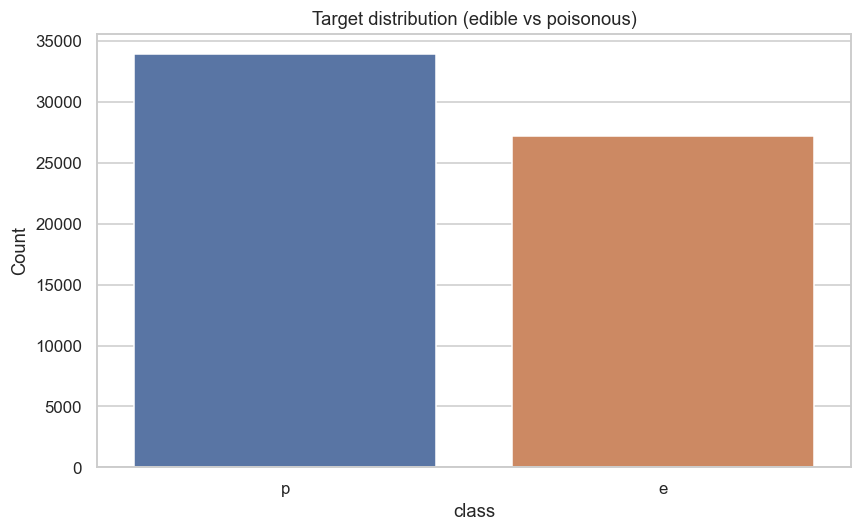

In [9]:
import warnings
warnings.filterwarnings("ignore")

vc = df[TARGET_COL].value_counts(dropna=False)
vp = df[TARGET_COL].value_counts(normalize=True, dropna=False) * 100

target_balance = pd.DataFrame({
    "count": vc,
    "percent": vp.round(2)
})

display(target_balance)

plt.figure(figsize=(8, 5))
sns.countplot(data=df, x=TARGET_COL, palette=["#4C72B0", "#DD8452"])
plt.title("Target distribution (edible vs poisonous)")
plt.xlabel(TARGET_COL)
plt.ylabel("Count")
plt.tight_layout()
plt.show()



## 11. Análisis Visual Exploratorio

Las visualizaciones ayudan a revelar patrones que son difíciles de identificar únicamente con tablas.

En esta sección, utilizamos:
- gráficos de barras para variables categóricas,
- histogramas para variables numéricas,
- diagramas de caja para detectar dispersión y valores atípicos,
- y gráficos comparativos agrupados por la clase objetivo.


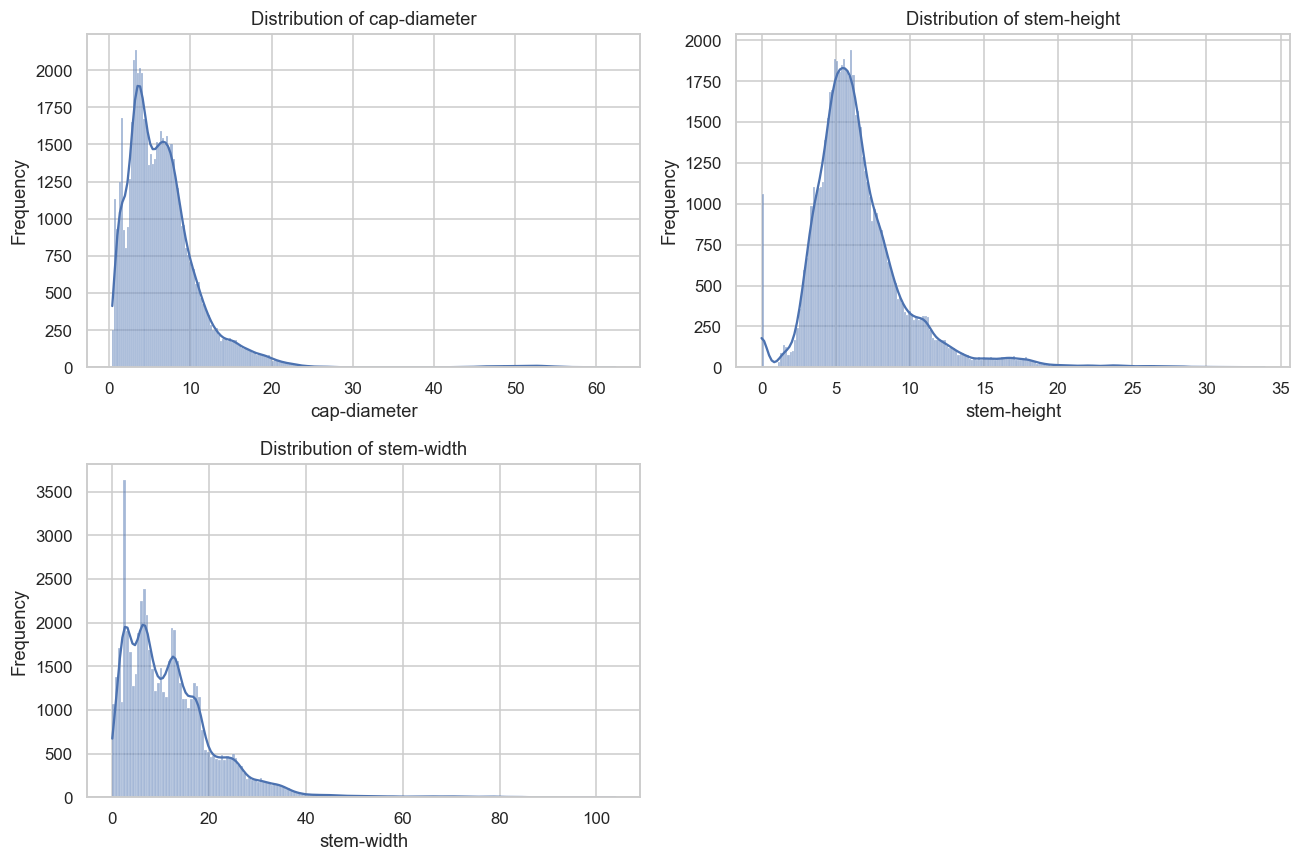

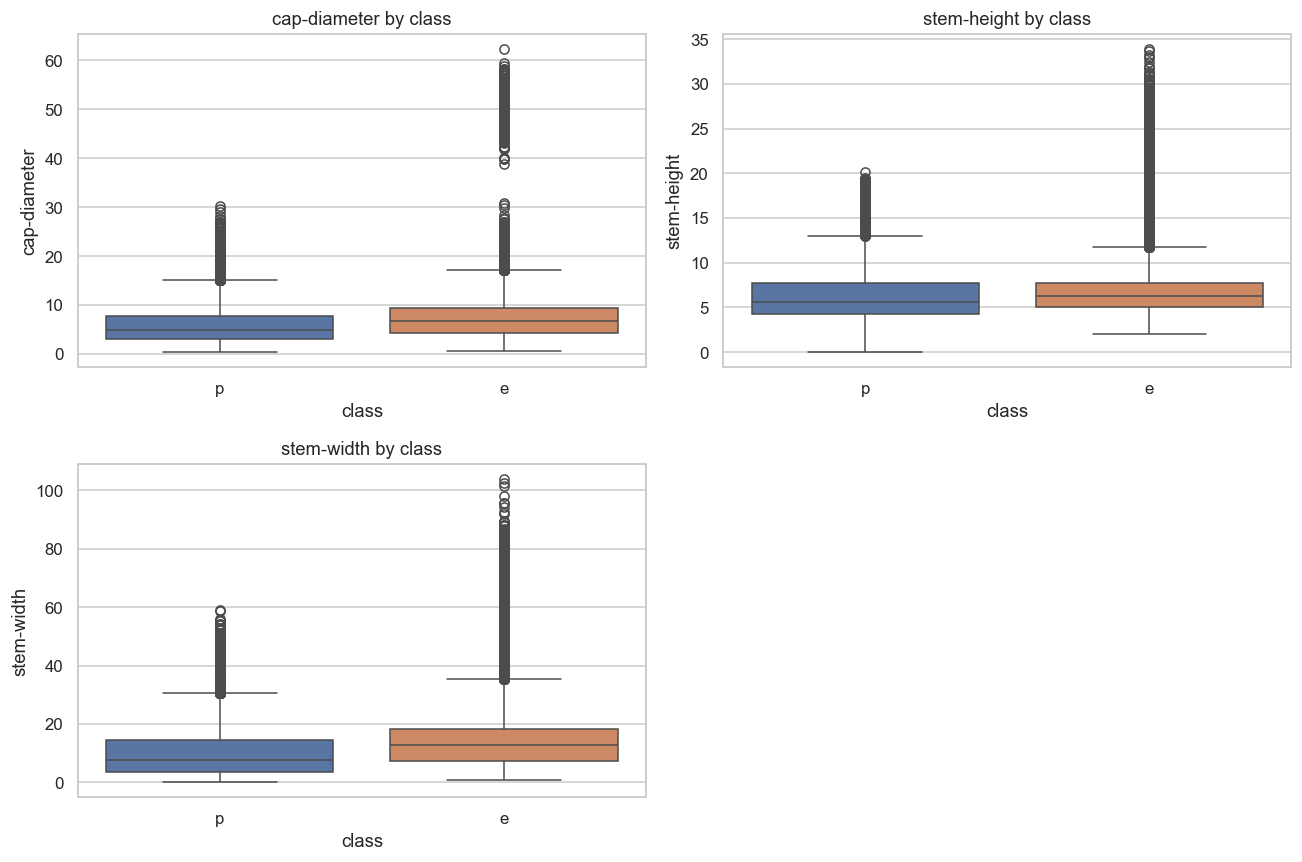

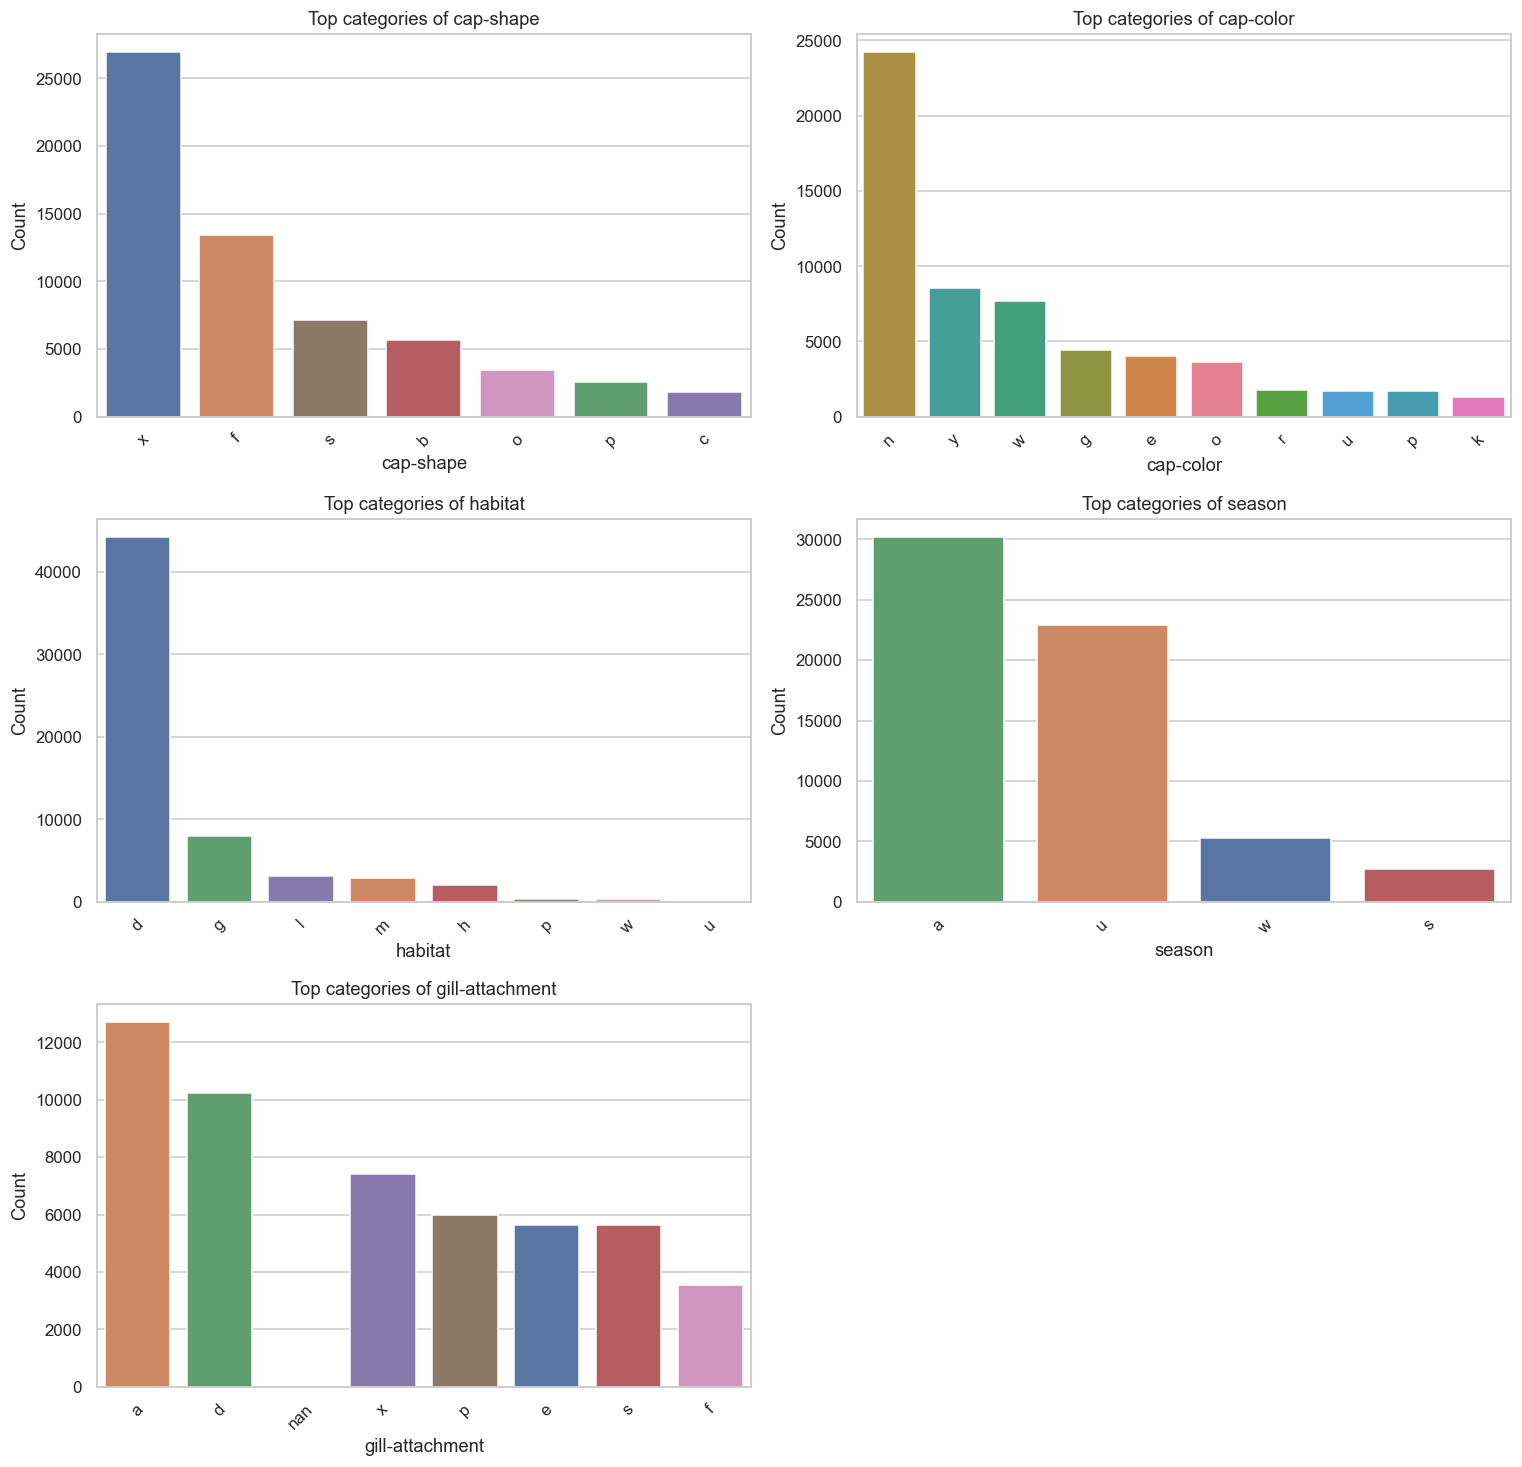

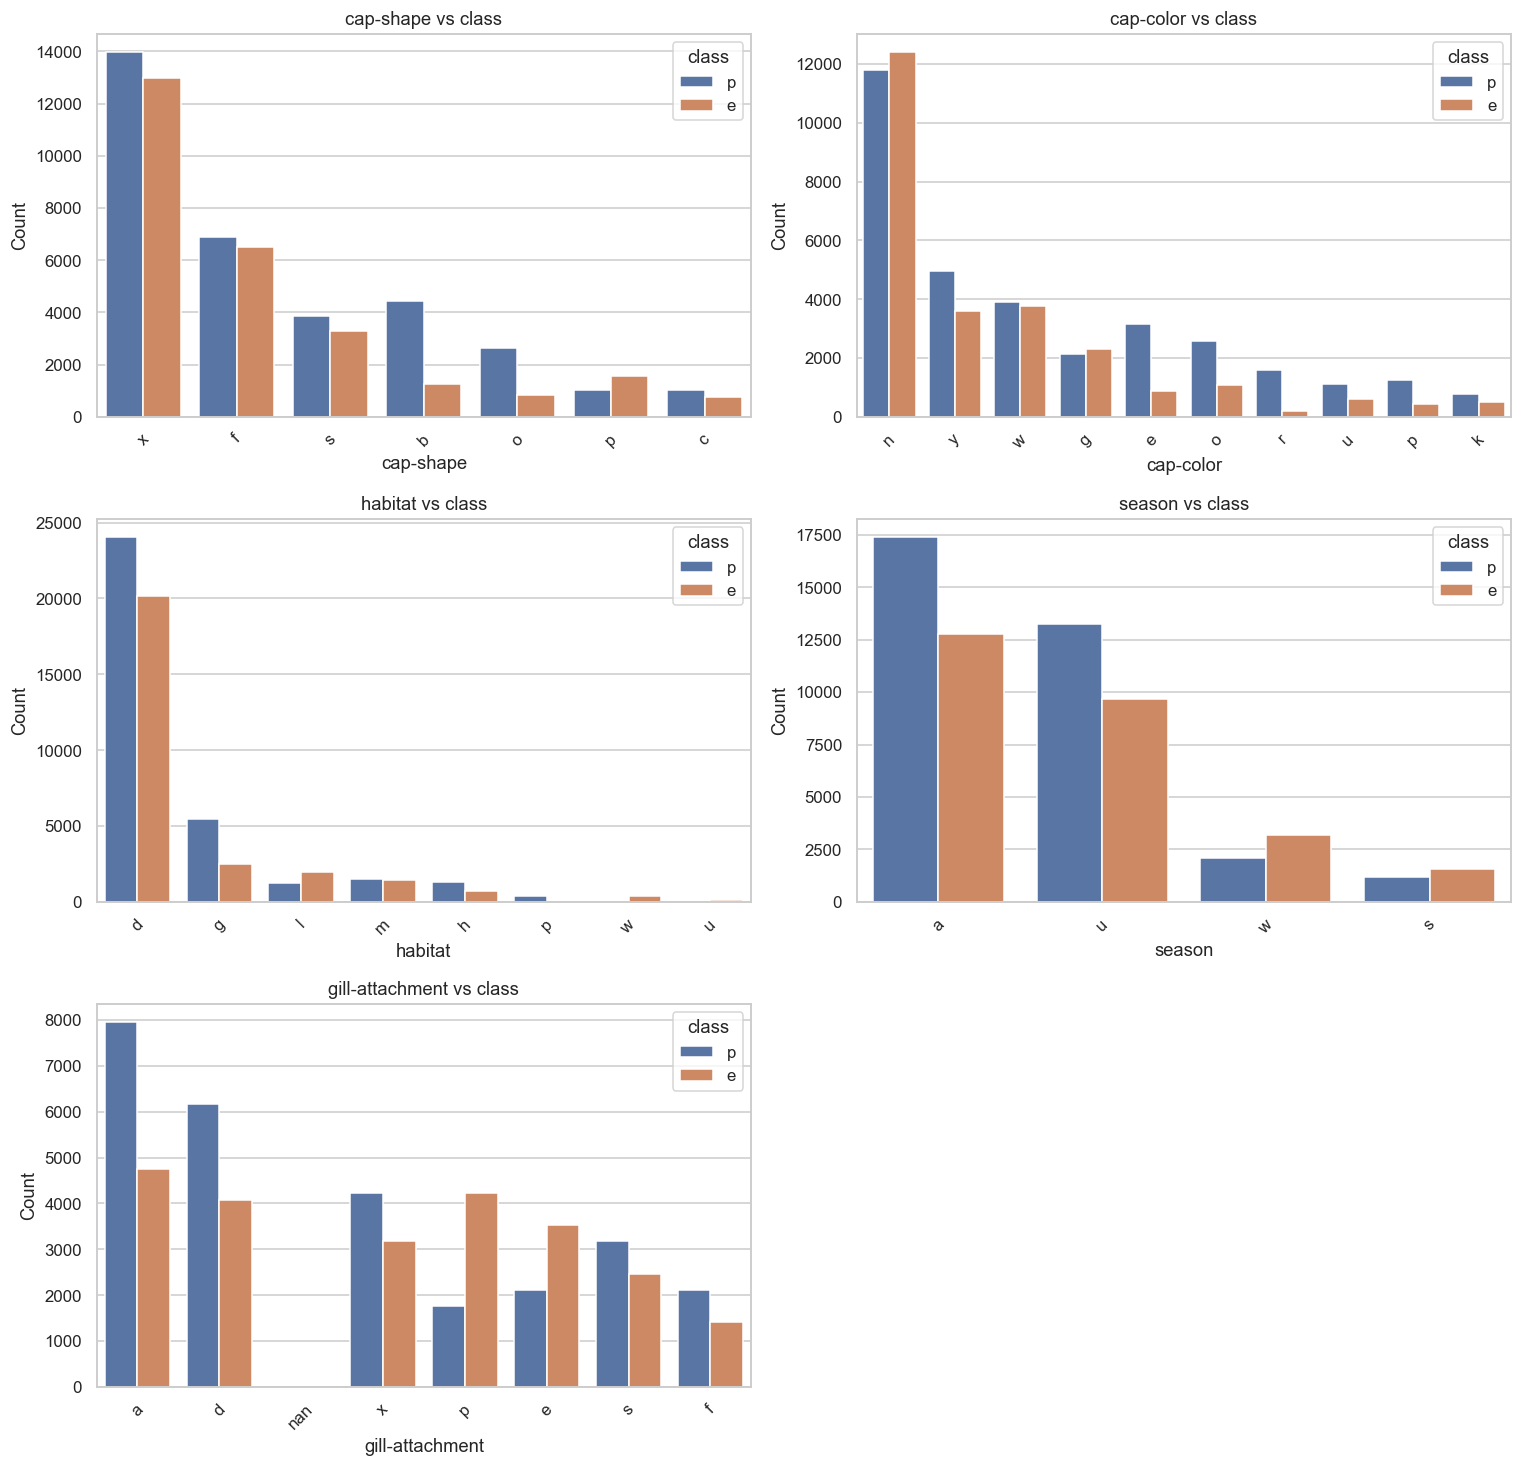

In [10]:
import math
import matplotlib.pyplot as plt
import seaborn as sns

# ============================
# Distribuciones de variables numéricas
# ============================
if len(numerical_cols) > 0:
    n = len(numerical_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        sns.histplot(df[col].dropna(), kde=True, ax=axes[i])
        axes[i].set_title(f"Distribution of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Frequency")

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns found.")


# ============================
# Boxplots por variable objetivo
# ============================
if len(numerical_cols) > 0:
    n = len(numerical_cols)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(12, 4 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(numerical_cols):
        sns.boxplot(data=df, x=TARGET_COL, y=col, hue=TARGET_COL, dodge=False, ax=axes[i])
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()
        axes[i].set_title(f"{col} by {TARGET_COL}")
        axes[i].set_xlabel(TARGET_COL)
        axes[i].set_ylabel(col)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No numerical columns available for boxplots.")


# ============================
# Selección de variables categóricas a visualizar
# ============================
selected_cats = [
    "cap-shape",
    "cap-color",
    "habitat",
    "season",
    "gill-attachment",
]
selected_cats = [c for c in selected_cats if c in df.columns]


# ============================
# Top categorías por variable categórica
# ============================
if len(selected_cats) > 0:
    n = len(selected_cats)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(selected_cats):
        top_order = df[col].value_counts(dropna=False).head(10).index
        sns.countplot(data=df, x=col, order=top_order, hue=col, dodge=False, ax=axes[i])
        if axes[i].get_legend() is not None:
            axes[i].get_legend().remove()
        axes[i].set_title(f"Top categories of {col}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No selected categorical columns found in the dataset.")


# ============================
# Variables categóricas vs variable objetivo
# ============================
if len(selected_cats) > 0:
    n = len(selected_cats)
    ncols = 2
    nrows = math.ceil(n / ncols)

    fig, axes = plt.subplots(nrows=nrows, ncols=ncols, figsize=(14, 4.5 * nrows))
    axes = axes.flatten()

    for i, col in enumerate(selected_cats):
        top_order = df[col].value_counts(dropna=False).head(10).index
        sns.countplot(data=df, x=col, hue=TARGET_COL, order=top_order, ax=axes[i])
        axes[i].set_title(f"{col} vs {TARGET_COL}")
        axes[i].set_xlabel(col)
        axes[i].set_ylabel("Count")
        axes[i].tick_params(axis="x", rotation=45)

    for j in range(i + 1, len(axes)):
        fig.delaxes(axes[j])

    plt.tight_layout()
    plt.show()
else:
    print("No selected categorical columns found for target comparison.")

## 12. Análisis de Correlación

El análisis de correlación se centra en las variables numéricas del dataset.  
Esto nos ayuda a identificar si algunas características están relacionadas linealmente y si puede existir redundancia o dependencia entre ellas.

Se incluye un mapa de calor de correlación para facilitar la interpretación.

,cap-diameter,stem-height,stem-width
cap-diameter,1.00000,0.422560,0.695330
stem-height,0.42256,1.000000,0.436117
stem-width,0.69533,0.436117,1.000000


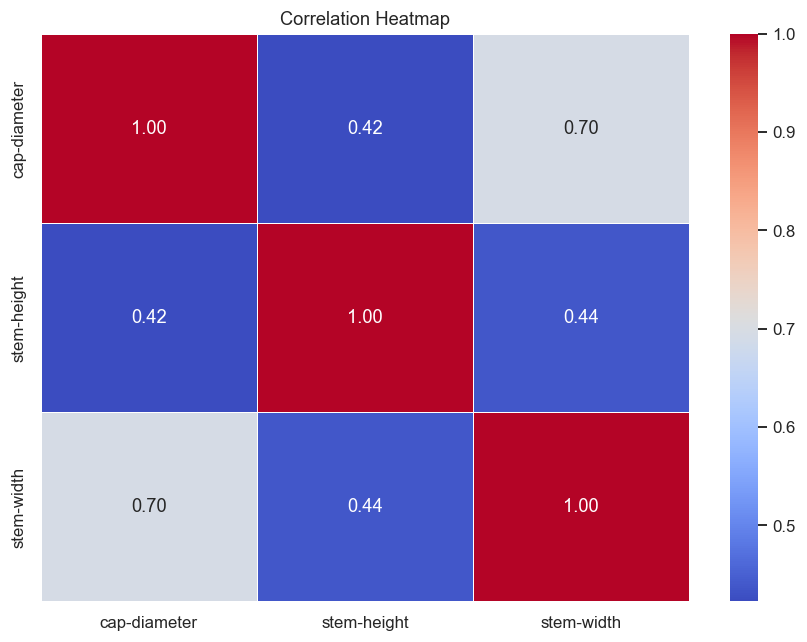

In [11]:
# ============================
# Matriz de correlación
# ============================
corr = df[numerical_cols].corr(method="pearson", numeric_only=True)
display(corr)

# ============================
# Heatmap de correlación
# ============================
plt.figure(figsize=(8, 6))
sns.heatmap(corr, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

Observamos una relación entre las variables 'stem-width' y 'cap-diameter' de acuerdo a su índice de correlación de 0.70

## 13. Principales Hallazgos

Con base en el análisis exploratorio, esta sección resume los hallazgos más importantes relacionados con:

la distribución de clases,
las variables relevantes,
los valores faltantes,
las categorías inusuales,
los valores atípicos,
y las posibles implicaciones para futuros flujos de trabajo de aprendizaje automático.


In [12]:
import numpy as np

def _fmt_pct(x: float) -> str:
    return f"{x:.2f}%"

n_rows, n_cols = df.shape
n_miss = int(df.isna().sum().sum())
n_dup = int(df.duplicated().sum())

vc = df[TARGET_COL].value_counts(normalize=True) * 100
p_pct = float(vc.get("p", np.nan))
e_pct = float(vc.get("e", np.nan))

outlier_lines = []
if not iqr_outliers.empty:
    for _, r in iqr_outliers.iterrows():
        outlier_lines.append(
            f"  - {r['column']}: {int(r['outlier_count'])} rows ({r['outlier_percent']:.2f}%) beyond 1.5×IQR fences"
        )
else:
    outlier_lines.append("  - No numerical columns or no IQR summary computed.")

corr_high = []
if len(numerical_cols) >= 2:
    c = df[numerical_cols].corr(numeric_only=True)
    for i, a in enumerate(numerical_cols):
        for b in numerical_cols[i + 1:]:
            val = c.loc[a, b]
            if abs(val) >= 0.7:
                corr_high.append(f"{a} vs {b}: {val:.3f}")

print("EDA concise summary (Secondary Mushroom Dataset)")
print("=" * 60)
print(f"Rows: {n_rows:,} | Features (total columns): {n_cols}")
print(f"Missing values (cell-level): {n_miss:,}")
print(f"Fully duplicated rows: {n_dup:,}")
print(f"Numerical features: {numerical_cols}")

if pd.notna(p_pct) and pd.notna(e_pct):
    print(f"Target balance ({TARGET_COL}): p={_fmt_pct(p_pct)}, e={_fmt_pct(e_pct)}")
else:
    print(f"Target balance: {vc.to_dict()}")

print("IQR-based outliers (1.5×IQR):")
print("\n".join(outlier_lines))

if corr_high:
    print("Strong linear correlations (|r| ≥ 0.7):")
    for line in corr_high:
        print("  -", line)
else:
    print("Strong linear correlations (|r| ≥ 0.7): none detected among current numerical features.")

print("=" * 60)
print("Next steps (Part II): preprocessing pipeline, encoding, baseline model, tracking, evaluation.")


EDA concise summary (Secondary Mushroom Dataset)
Rows: 61,069 | Features (total columns): 21
Missing values (cell-level): 307,463
Fully duplicated rows: 146
Numerical features: ['cap-diameter', 'stem-height', 'stem-width']
Target balance (class): p=55.49%, e=44.51%
IQR-based outliers (1.5×IQR):
  - cap-diameter: 2400 rows (3.93%) beyond 1.5×IQR fences
  - stem-height: 3169 rows (5.19%) beyond 1.5×IQR fences
  - stem-width: 1967 rows (3.22%) beyond 1.5×IQR fences
Strong linear correlations (|r| ≥ 0.7): none detected among current numerical features.
Next steps (Part II): preprocessing pipeline, encoding, baseline model, tracking, evaluation.


## Parte II — Limpieza, preparación, balanceo y modelado

Esta sección **continúa** el EDA anterior sin modificar las celdas previas. Aquí se prepara un conjunto de entrenamiento/validación reproducible, se evita *data leakage* (SMOTE y el ajuste del preprocesador solo con datos de entrenamiento) y el flujo queda encapsulado en un `Pipeline` compatible con extensiones futuras (**MLflow** para trazabilidad de experimentos y **Prefect** para orquestación de tareas).


### Dependencias adicionales

Para **SMOTE** se usa `imbalanced-learn` (import `imblearn`). Si falta en el entorno:

`pip install imbalanced-learn`


In [13]:
# Integración futura: en MLflow se registrarían run_name, params del Pipeline y métricas;
# en Prefect, cada bloque lógico (carga, limpieza, entrenamiento, evaluación) podría ser un @task dentro de un @flow.

from sklearn.compose import ColumnTransformer
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import OneHotEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, f1_score

from imblearn.over_sampling import SMOTE
from imblearn.pipeline import Pipeline as ImbPipeline


### 1. Limpieza de datos

En `secondary_data.csv` muchas columnas (velo, esporas, etc.) tienen **ausencias estructurales**; si se hace `dropna()` sobre *todas* las columnas, **casi ninguna fila sobrevive**. Por eso, después de auditar los faltantes, se **retiran columnas con fracción de NaN muy alta** (umbral configurable) y luego se eliminan filas con NaN en el subconjunto restante. Esto mantiene el espíritu de *complete-case* sin un conjunto vacío.


In [14]:
# Trabajamos sobre una copia para no alterar el DataFrame del EDA al re-ejecutar el notebook.
df_model = df.copy()

n_before = len(df_model)
dup_mask = df_model.duplicated()
n_dup = int(dup_mask.sum())
df_model = df_model.loc[~dup_mask].reset_index(drop=True)
print(f"Filas duplicadas eliminadas: {n_dup} (quedan {len(df_model)} de {n_before}).")

# Valores "?" como ausentes (regex=False: "?" no se interpreta como metacarácter regex)
df_model = df_model.replace("?", np.nan, regex=False)

# Auditoría de faltantes por columna
missing_per_col = df_model.isna().sum()
missing_total = int(missing_per_col.sum())
print("Valores faltantes por columna (top 15):")
display(missing_per_col.sort_values(ascending=False).head(15))
print(f"Total de celdas con NaN: {missing_total}")
print("Filas con al menos un NaN (antes de recortar columnas):", int(df_model.isna().any(axis=1).sum()))

# Columnas con demasiados faltantes: quitarlas antes del dropna filas (parametrizable para MLflow/Prefect)
MISSING_FRACTION_DROP_COL = 0.4
frac_na = df_model.isna().mean()
drop_cols = frac_na[frac_na > MISSING_FRACTION_DROP_COL].index.tolist()
df_model = df_model.drop(columns=drop_cols)
print(f"Columnas eliminadas (>{MISSING_FRACTION_DROP_COL:.0%} NaN): {drop_cols}")

n_before_dropna = len(df_model)
df_model = df_model.dropna().reset_index(drop=True)
print(f"Filas eliminadas por NaN: {n_before_dropna - len(df_model)} (shape final {df_model.shape}).")


Filas duplicadas eliminadas: 146 (quedan 60923 de 61069).
Valores faltantes por columna (top 15):


veil-type            57746
spore-print-color    54597
veil-color           53510
stem-root            51536
stem-surface         38122
gill-spacing         25062
cap-surface          14120
gill-attachment       9855
ring-type             2471
cap-color                0
cap-shape                0
cap-diameter             0
class                    0
stem-height              0
stem-width               0
dtype: int64

Total de celdas con NaN: 307019
Filas con al menos un NaN (antes de recortar columnas): 60923
Columnas eliminadas (>40% NaN): ['gill-spacing', 'stem-root', 'stem-surface', 'veil-type', 'veil-color', 'spore-print-color']
Filas eliminadas por NaN: 23975 (shape final (36948, 15)).


### 2. Preparación de datos (X, y, codificación del target, split)


In [15]:
X = df_model.drop(columns=[TARGET_COL])
y = df_model[TARGET_COL].map({"p": 1, "e": 0})

if y.isna().any():
    raise ValueError("Hay etiquetas en class distintas de p/e; revisar datos.")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y,
)
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Distribución y (train):\n", y_train.value_counts(normalize=True))


Train: (29558, 14) Test: (7390, 14)
Distribución y (train):
 class
1    0.54141
0    0.45859
Name: proportion, dtype: float64


### 3. Transformación — `ColumnTransformer` + `OneHotEncoder`

Solo las columnas **categóricas** se codifican con `OneHotEncoder` (`handle_unknown="ignore"` ayuda ante categorías nuevas en inferencia). Las numéricas se pasan sin cambio (`passthrough`). La matriz resultante es densa para compatibilidad con **SMOTE**.


In [16]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns.tolist()
numerical_features = X_train.select_dtypes(include=["number"]).columns.tolist()

preprocessor = ColumnTransformer(
    transformers=[
        (
            "cat",
            OneHotEncoder(handle_unknown="ignore", sparse_output=False),
            categorical_features,
        ),
        ("num", "passthrough", numerical_features),
    ],
    remainder="drop",
    verbose_feature_names_out=False,
)

print("Categóricas:", len(categorical_features), "Numéricas:", len(numerical_features))


Categóricas: 11 Numéricas: 3


### 4. Balanceo — SMOTE (solo entrenamiento)

SMOTE (*Synthetic Minority Over-sampling Technique*) genera ejemplos sintéticos de la clase minoritaria interpolando vecinos en el espacio de características **ya numérico** (después del one-hot). Se usa con clases desbalanceadas para reducir el sesgo del modelo hacia la clase mayoritaria.

**Importante:** SMOTE va **después** del preprocesamiento y solo dentro del `fit` del pipeline de `imblearn`; en `predict` no se aplica sobremuestreo, así se evita filtrar información del conjunto de prueba al entrenamiento.


### 5. Modelado — `Pipeline` (preprocesamiento + SMOTE + `RandomForestClassifier`)

Se usa `imblearn.pipeline.Pipeline` porque **SMOTE** no forma parte de `sklearn.pipeline`; la API es la misma (`fit` / `predict` / `get_params`) y encaja con **GridSearchCV**, **MLflow** (`sklearn.log_model` con `signature`) y serialización con `joblib`.


In [17]:
model_pipeline = ImbPipeline(
    steps=[
        ("preprocess", preprocessor),
        (
            "smote",
            SMOTE(random_state=42),
        ),
        (
            "classifier",
            RandomForestClassifier(
                n_estimators=200,
                random_state=42,
                n_jobs=-1,
                class_weight=None,  # el balanceo principal lo aporta SMOTE en train
            ),
        ),
    ]
)

model_pipeline.fit(X_train, y_train)
print("Entrenamiento finalizado.")


Entrenamiento finalizado.


### 6. Evaluación

El **F1-score** combina precisión y recall (media armónica). En **detección de hongos venenosos** interesa equilibrar no pasar por alto un hongo venenos (recall de la clase positiva) y no clasificar erróneamente comestibles como venenosos (precisión). Con clases desbalanceadas, el F1 es más informativo que la accuracy. `classification_report` muestra F1 por clase y promedios **macro** / **weighted**.


In [18]:
y_pred = model_pipeline.predict(X_test)

print(classification_report(y_test, y_pred, digits=4, target_names=["comestible (0)", "venenoso (1)"]))

f1_weighted = f1_score(y_test, y_pred, average="weighted")
f1_macro = f1_score(y_test, y_pred, average="macro")
f1_venenoso = f1_score(y_test, y_pred, pos_label=1)
print(f"F1 (clase venenosa, label=1): {f1_venenoso:.4f}")
print(f"F1 macro: {f1_macro:.4f} | F1 weighted: {f1_weighted:.4f}")


                precision    recall  f1-score   support

comestible (0)     0.9994    1.0000    0.9997      3389
  venenoso (1)     1.0000    0.9995    0.9998      4001

      accuracy                         0.9997      7390
     macro avg     0.9997    0.9998    0.9997      7390
  weighted avg     0.9997    0.9997    0.9997      7390

F1 (clase venenosa, label=1): 0.9998
F1 macro: 0.9997 | F1 weighted: 0.9997
